# FEM vs 2D MBIR on Real Single-Image Data

This notebook keeps a single compact workflow for the real single-image dataset:
1. load the magnetic and MIP phase maps
2. build a simple 3D support from the MIP-derived thickness
3. reconstruct a 2D MBIR baseline
4. run one 3D FEM-style reconstruction from the MBIR warm start
5. compare phase fit and inspect the reconstructed volume

There is no ground-truth magnetization here, so the comparison is intentionally practical: phase error, contour agreement, projected-field behavior, and a quick look through the recovered volume.

## 1. Setup
Import the small set of dependencies used by the simplified workflow.

In [1]:
import os
from pathlib import Path

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.1"

import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter, zoom

from libertem_holo.base.mbir import (
    CombinedBackend,
    NeuralMagCritic,
    SmoothnessBackend,
    WeightedBackend,
    add_units_to_inputs,
    forward_model_2d,
    lcurve_sweep_vmap,
    make_quantity,
    reconstruct_2d,
    support_center_yx,
    )
from libertem_holo.base.mbir.inversion import invert_magnetization
from libertem_holo.base.mbir.physical import estimate_thickness_from_mip_phase

/Users/landers/.conda/envs/holography_error/lib/python3.14/site-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda13_plugin version 0.9.1 is installed, but it is not compatible with the installed jaxlib version 0.9.0, so it will not be used.
  warnings.warn(


## 2. Minimal Helpers
Keep only the utilities needed for path resolution, preprocessing, support construction, reconstruction, and plotting.

In [2]:
def resolve_phase_paths():
    notebook_dir = Path.cwd().resolve()
    candidates = [
        notebook_dir,
        notebook_dir.parent / "MBIR",
        notebook_dir.parent,
        Path("/Users/landers/LiberTEM-holo/notebooks/MBIR"),
    ]
    for base in candidates:
        mag_path = base / "PosC_alpha0_phase_mag.npy"
        mip_path = base / "PosC_alpha0_phase_mip.npy"
        if mag_path.exists() and mip_path.exists():
            return mag_path, mip_path
    raise FileNotFoundError(
        "Could not find PosC_alpha0_phase_[mag|mip].npy in expected notebook locations."
    )


def crop_to_mask(arrays, mask, pad=24):
    ys, xs = np.where(mask)
    y0 = max(int(ys.min()) - pad, 0)
    y1 = min(int(ys.max()) + pad + 1, mask.shape[0])
    x0 = max(int(xs.min()) - pad, 0)
    x1 = min(int(xs.max()) + pad + 1, mask.shape[1])
    side = max(y1 - y0, x1 - x0)
    cy = 0.5 * (y0 + y1)
    cx = 0.5 * (x0 + x1)
    y0 = max(int(round(cy - side / 2)), 0)
    x0 = max(int(round(cx - side / 2)), 0)
    y1 = min(y0 + side, mask.shape[0])
    x1 = min(x0 + side, mask.shape[1])
    y0 = y1 - side
    x0 = x1 - side
    return [arr[y0:y1, x0:x1] for arr in arrays]


def resize_square(arr, target, order=1):
    scale = target / arr.shape[0]
    return np.asarray(zoom(arr, zoom=scale, order=order), dtype=np.float32)


def build_centered_rho(thickness_nm, pixel_size_nm, nz=32):
    thickness_nm = np.asarray(thickness_nm, dtype=np.float32)
    if int(nz) == 1:
        return (thickness_nm > 0.0)[None, :, :].astype(np.float32)

    thickness_px = thickness_nm / float(pixel_size_nm)
    z0 = 0.5 * (int(nz) - thickness_px)
    z1 = z0 + thickness_px
    z_lo = np.arange(int(nz), dtype=np.float32)[:, None, None]
    z_hi = z_lo + 1.0
    fill = np.clip(
        np.minimum(z_hi, z1[None, :, :]) - np.maximum(z_lo, z0[None, :, :]),
        0.0,
        1.0,
    )
    return np.asarray(fill, dtype=np.float32)


def projected_from_volume(rho_zyx, m_zyxc):
    return np.sum(np.asarray(rho_zyx)[..., None] * np.asarray(m_zyxc), axis=0)[..., :2]


def normalize_field(m, rho, eps=1e-6):
    m = np.asarray(m, dtype=np.float32)
    rho = np.asarray(rho, dtype=np.float32)
    norms = np.linalg.norm(m, axis=-1, keepdims=True)
    safe_norms = np.where(norms > eps, norms, 1.0)
    unit = m / safe_norms
    fallback = np.zeros_like(unit)
    fallback[..., 0] = 1.0
    unit = np.where(norms > eps, unit, fallback)
    return np.where(rho[..., None] > 0.05, unit, 0.0).astype(np.float32)


def extrude_projected_init(rho, proj_2d):
    init = np.zeros(np.asarray(rho).shape + (3,), dtype=np.float32)
    init[..., 0] = np.asarray(proj_2d, dtype=np.float32)[None, ..., 0]
    init[..., 1] = np.asarray(proj_2d, dtype=np.float32)[None, ..., 1]
    return normalize_field(init, rho)


def phase_rms(pred, truth):
    pred = np.asarray(pred, dtype=np.float64)
    truth = np.asarray(truth, dtype=np.float64)
    return float(np.sqrt(np.mean((pred - truth) ** 2)))


def contour_correlation(pred, truth, *, smooth=4, contour=16):
    pred_contour = np.cos(gaussian_filter(np.asarray(pred), sigma=smooth) * contour)
    truth_contour = np.cos(gaussian_filter(np.asarray(truth), sigma=smooth) * contour)
    return float(np.corrcoef(pred_contour.ravel(), truth_contour.ravel())[0, 1])


def make_neuralmag_backend(rho, pixel_size_nm, msat=4e5, aex=1.3e-11):
    import neuralmag as nm

    mesh = nm.Mesh(rho.shape, (pixel_size_nm * 1e-9,) * 3)
    state = nm.State(mesh)
    state.rho = nm.CellFunction(state, tensor=state.tensor(np.asarray(rho, dtype=np.float32)))
    state.material.Ms = nm.CellFunction(state).fill(msat)
    state.material.A = nm.CellFunction(state).fill(aex)
    state.m = nm.VectorCellFunction(
        state,
        tensor=state.tensor(np.zeros(rho.shape + (3,), dtype=np.float32)),
    )
    nm.ExchangeField().register(state, "exchange")
    nm.DemagField(p=1).register(state, "demag")
    return NeuralMagCritic.from_state(state, terms=("exchange", "demag"))


def make_fem_backend(rho, pixel_size_nm, *, smoothness_weight=0.0):
    base_backend = make_neuralmag_backend(rho, pixel_size_nm)
    if smoothness_weight == 0.0:
        return base_backend
    return CombinedBackend(
        base_backend,
        WeightedBackend(SmoothnessBackend(), weight=smoothness_weight),
    )


def run_fem_reconstruction(
    phi_meas,
    rho,
    pixel_size_q,
    proj_init,
    *,
    lambda_phys=0.0,
    optimizer="bb",
    physics_objective="energy",
    max_iter=400,
    lr=5e-2,
    smoothness_weight=0.0,
    projection_threshold=0.0,
    fit_ramp=True,
):
    backend = make_fem_backend(
        rho,
        float(pixel_size_q.value),
        smoothness_weight=smoothness_weight,
    )
    init_guess = extrude_projected_init(rho, proj_init)
    result = invert_magnetization(
        np.asarray(phi_meas, dtype=np.float32),
        rho,
        backend,
        pixel_size=pixel_size_q,
        lambda_phys=lambda_phys,
        max_iter=max_iter,
        lr=lr,
        init=init_guess.astype(np.float32),
        axis="z",
        projection_threshold=projection_threshold,
        fit_ramp=fit_ramp,
        optimizer=optimizer,
        physics_objective=physics_objective,
    )
    return backend, init_guess, result


def rho_to_maglab_layout(rho_zyx):
    return np.transpose(np.asarray(rho_zyx, dtype=np.float32), (1, 2, 0))


def volume_to_maglab_layout(m_zyxc):
    return np.transpose(np.asarray(m_zyxc, dtype=np.float32), (3, 1, 2, 0))


def volume_from_maglab_layout(m_cyxz):
    return np.transpose(np.asarray(m_cyxz, dtype=np.float32), (3, 1, 2, 0))


def run_maglab_reconstruction(
    phi_meas,
    rho,
    pixel_size_q,
    proj_init,
    *,
    msat=4e5,
    aex=1.3e-11,
    phase_weight=25.0,
    n_steps=150,
    maxtau=1.0,
    mintau=1e-10,
    phase_sign=1.0,
    fit_ramp=True,
    device=None,
):
    import maglab
    import torch

    phi_meas = np.asarray(phi_meas, dtype=np.float32)
    if phi_meas.ndim != 2 or phi_meas.shape[0] != phi_meas.shape[1]:
        raise ValueError("MagLab PhaseMapper expects a square phase image.")

    rho = np.asarray(rho, dtype=np.float32)
    rho_maglab = rho_to_maglab_layout(rho)
    init_guess = extrude_projected_init(rho, proj_init)
    spin0 = volume_to_maglab_layout(init_guess)
    dx_m = float(pixel_size_q.value) * 1e-9

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    device = torch.device(device)

    micro = maglab.Micro(phi_meas.shape[0], phi_meas.shape[1], rho_maglab.shape[2], dx_m)
    micro.set_Ms(msat * torch.from_numpy(rho_maglab))
    micro.add_exch(aex)
    micro.add_demag()
    micro = micro.to(device)
    micro.Ms = micro.Ms.to(device)
    micro.geo = micro.geo.to(device)
    micro.init_m0(torch.from_numpy(spin0).to(device))

    mapper = maglab.PhaseMapper(phi_meas.shape[0], dx=dx_m).to(device)
    optimizer = maglab.sd.SteepestDescent(
        micro.shape,
        maxtau=maxtau,
        mintau=mintau,
    ).to(device)
    target = torch.from_numpy(phi_meas).to(device)

    if fit_ramp:
        yy, xx = torch.meshgrid(
            torch.arange(phi_meas.shape[0], dtype=target.dtype, device=device),
            torch.arange(phi_meas.shape[1], dtype=target.dtype, device=device),
            indexing="ij",
        )
        X = torch.stack(
            [torch.ones_like(xx), yy, xx],
            dim=-1,
        ).reshape(-1, 3)
        XtX_inv = torch.linalg.inv(X.T @ X)
        X_pinv = XtX_inv @ X.T

    loss_history = []
    tau_history = []

    for _ in range(int(n_steps)):
        spin = micro.get_spin()
        phase_pred_raw = phase_sign * mapper(spin, Ms=micro.Ms)
        if fit_ramp:
            residual = (target - phase_pred_raw).reshape(-1)
            coeff = X_pinv @ residual
            ramp = (X @ coeff).reshape_as(target)
            phase_pred = phase_pred_raw + ramp
        else:
            phase_pred = phase_pred_raw
        data_loss = torch.mean((phase_pred - target) ** 2)
        phase_field = micro.get_field_from_loss(phase_weight * data_loss, spin)
        total_field = micro.get_total_field(spin) + phase_field
        new_spin = optimizer(spin, total_field)
        micro.init_m0(new_spin)

        loss_history.append(float(data_loss.detach().cpu()))
        tau_history.append(float(optimizer.tau))

    with torch.no_grad():
        spin = micro.get_spin()
        phase_pred_raw = phase_sign * mapper(spin, Ms=micro.Ms)
        if fit_ramp:
            residual = (target - phase_pred_raw).reshape(-1)
            coeff = X_pinv @ residual
            ramp = (X @ coeff).reshape_as(target)
            phase_pred = phase_pred_raw + ramp
            ramp_coeffs = coeff.detach().cpu().numpy()
            ramp_map = ramp.detach().cpu().numpy()
        else:
            phase_pred = phase_pred_raw
            ramp_coeffs = np.zeros(3, dtype=np.float32)
            ramp_map = np.zeros_like(phi_meas, dtype=np.float32)

        m_recon = volume_from_maglab_layout(spin.detach().cpu().numpy())
        phi_pred = phase_pred.detach().cpu().numpy()
        phi_pred_raw = phase_pred_raw.detach().cpu().numpy()

    return {
        "device": str(device),
        "fit_ramp": bool(fit_ramp),
        "ramp_coeffs": np.asarray(ramp_coeffs, dtype=np.float64),
        "ramp_map": np.asarray(ramp_map, dtype=np.float32),
        "init_guess": init_guess,
        "m_recon": m_recon,
        "phi_pred": phi_pred,
        "phi_pred_raw": phi_pred_raw,
        "proj_recon": projected_from_volume(rho, m_recon),
        "loss_history": np.asarray(loss_history, dtype=np.float64),
        "tau_history": np.asarray(tau_history, dtype=np.float64),
    }


def show_volume_slices(m_recon, rho_ref, title, stride=4):
    slice_indices = list(range(0, m_recon.shape[0], stride))
    components = [(0, "Mx"), (1, "My"), (2, "Mz")]
    fig, axes = plt.subplots(
        len(slice_indices),
        3,
        figsize=(8, 2.0 * len(slice_indices)),
        squeeze=False,
    )
    for row_idx, z_idx in enumerate(slice_indices):
        support = rho_ref[z_idx] > 0.25
        for comp_idx, comp_name in components:
            ax = axes[row_idx, comp_idx]
            ax.imshow(m_recon[z_idx, :, :, comp_idx], vmin=-1, vmax=1, cmap="RdBu_r")
            ax.contour(support, levels=[0.5], colors="k", linewidths=0.4)
            if row_idx == 0:
                ax.set_title(comp_name, fontsize=9)
            ax.set_ylabel(f"z={z_idx}", fontsize=8)
            ax.set_xticks([])
            ax.set_yticks([])
    plt.suptitle(title, y=1.0)
    plt.tight_layout()
    plt.show()

In [3]:
def run_maglab_reconstruction(
    phi_meas,
    rho,
    pixel_size_q,
    proj_init,
    *,
    msat=4e5,
    aex=1.3e-11,
    phase_weight=25.0,
    n_steps=150,
    maxtau=1.0,
    mintau=1e-10,
    phase_sign=1.0,
    fit_ramp=True,
    mask=None,
    use_masked_loss=True,
    fit_ramp_on_mask=True,
    device=None,
):
    import maglab
    import torch

    phi_meas = np.asarray(phi_meas, dtype=np.float32)
    if phi_meas.ndim != 2 or phi_meas.shape[0] != phi_meas.shape[1]:
        raise ValueError("MagLab PhaseMapper expects a square phase image.")

    rho = np.asarray(rho, dtype=np.float32)
    rho_maglab = rho_to_maglab_layout(rho)
    init_guess = extrude_projected_init(rho, proj_init)
    spin0 = volume_to_maglab_layout(init_guess)
    dx_m = float(pixel_size_q.value) * 1e-9

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    device = torch.device(device)

    micro = maglab.Micro(phi_meas.shape[0], phi_meas.shape[1], rho_maglab.shape[2], dx_m)
    micro.set_Ms(msat * torch.from_numpy(rho_maglab))
    micro.add_exch(aex)
    micro.add_demag()
    micro = micro.to(device)
    micro.Ms = micro.Ms.to(device)
    micro.geo = micro.geo.to(device)
    micro.init_m0(torch.from_numpy(spin0).to(device))

    mapper = maglab.PhaseMapper(phi_meas.shape[0], dx=dx_m).to(device)
    optimizer = maglab.sd.SteepestDescent(
        micro.shape,
        maxtau=maxtau,
        mintau=mintau,
    ).to(device)

    target = torch.from_numpy(phi_meas).to(device)

    if mask is None:
        mask_t = torch.ones_like(target)
    else:
        mask_arr = np.asarray(mask, dtype=np.float32)
        if mask_arr.shape != phi_meas.shape:
            raise ValueError("mask shape must match phi_meas shape")
        mask_t = torch.from_numpy(mask_arr).to(device)
    mask_t = (mask_t > 0.5).to(target.dtype)
    mask_flat_bool = mask_t.reshape(-1) > 0.0

    if fit_ramp:
        yy, xx = torch.meshgrid(
            torch.arange(phi_meas.shape[0], dtype=target.dtype, device=device),
            torch.arange(phi_meas.shape[1], dtype=target.dtype, device=device),
            indexing="ij",
        )
        X_full = torch.stack(
            [torch.ones_like(xx), yy, xx],
            dim=-1,
        ).reshape(-1, 3)
        if fit_ramp_on_mask and torch.count_nonzero(mask_flat_bool) >= 3:
            X_fit = X_full[mask_flat_bool]
        else:
            X_fit = X_full
        X_pinv = torch.linalg.pinv(X_fit)

    loss_history = []
    tau_history = []

    def _weighted_mse(err_map):
        if use_masked_loss:
            denom = torch.clamp(mask_t.sum(), min=1.0)
            return torch.sum(mask_t * (err_map ** 2)) / denom
        return torch.mean(err_map ** 2)

    for _ in range(int(n_steps)):
        spin = micro.get_spin()
        phase_pred_raw = phase_sign * mapper(spin, Ms=micro.Ms)

        if fit_ramp:
            residual = (target - phase_pred_raw).reshape(-1)
            if fit_ramp_on_mask and torch.count_nonzero(mask_flat_bool) >= 3:
                coeff = X_pinv @ residual[mask_flat_bool]
            else:
                coeff = X_pinv @ residual
            ramp = (X_full @ coeff).reshape_as(target)
            phase_pred = phase_pred_raw + ramp
        else:
            phase_pred = phase_pred_raw

        err = phase_pred - target
        data_loss = _weighted_mse(err)
        phase_field = micro.get_field_from_loss(phase_weight * data_loss, spin)
        total_field = micro.get_total_field(spin) + phase_field
        new_spin = optimizer(spin, total_field)
        micro.init_m0(new_spin)

        loss_history.append(float(data_loss.detach().cpu()))
        tau_history.append(float(optimizer.tau))

    with torch.no_grad():
        spin = micro.get_spin()
        phase_pred_raw = phase_sign * mapper(spin, Ms=micro.Ms)
        if fit_ramp:
            residual = (target - phase_pred_raw).reshape(-1)
            if fit_ramp_on_mask and torch.count_nonzero(mask_flat_bool) >= 3:
                coeff = X_pinv @ residual[mask_flat_bool]
            else:
                coeff = X_pinv @ residual
            ramp = (X_full @ coeff).reshape_as(target)
            phase_pred = phase_pred_raw + ramp
            ramp_coeffs = coeff.detach().cpu().numpy()
            ramp_map = ramp.detach().cpu().numpy()
        else:
            phase_pred = phase_pred_raw
            ramp_coeffs = np.zeros(3, dtype=np.float32)
            ramp_map = np.zeros_like(phi_meas, dtype=np.float32)

        m_recon = volume_from_maglab_layout(spin.detach().cpu().numpy())
        phi_pred = phase_pred.detach().cpu().numpy()
        phi_pred_raw = phase_pred_raw.detach().cpu().numpy()

    return {
        "device": str(device),
        "fit_ramp": bool(fit_ramp),
        "use_masked_loss": bool(use_masked_loss),
        "fit_ramp_on_mask": bool(fit_ramp_on_mask),
        "ramp_coeffs": np.asarray(ramp_coeffs, dtype=np.float64),
        "ramp_map": np.asarray(ramp_map, dtype=np.float32),
        "init_guess": init_guess,
        "m_recon": m_recon,
        "phi_pred": phi_pred,
        "phi_pred_raw": phi_pred_raw,
        "proj_recon": projected_from_volume(rho, m_recon),
        "loss_history": np.asarray(loss_history, dtype=np.float64),
        "tau_history": np.asarray(tau_history, dtype=np.float64),
    }

## 3. Configuration and Data Preparation
Set a few high-level parameters, then load, crop, downsample, and convert the real phase data into a 3D support volume.

In [15]:
DATA_CONFIG = {
    "pixel_size_nm_full": 0.58,
    "mip_threshold": 3.0,
    "crop_pad": 40,
    "target_size": 96,
    "thickness_scale": 0.4,
    "support_nz": 32,
}

FEM_CONFIG = {
    "optimizer": "lbfgs",
    "physics_objective": "energy",
    "lambda_phys": 0.0,
    "smoothness_weight": 0.0,
    "max_iter": 300,
    "lr": 1.0,
    "projection_threshold": 0.0,
    "fit_ramp": True,
}

MAGLAB_CONFIG = {
    "msat": 4e5,
    "aex": 1.3e-11,
    "phase_weight": 1.0,
    "n_steps": 2000,
    "maxtau": 1.0,
    "mintau": 1e-10,
    "phase_sign": -1.0,
    "fit_ramp": True,
    "use_masked_loss": False,
    "fit_ramp_on_mask": False,
    "device": None,
}

print("Data config:", DATA_CONFIG)
print("FEM config:", FEM_CONFIG)
print("MagLab config:", MAGLAB_CONFIG)
print("With lambda_phys=0.0, physics_objective does not change the loss.")
print("Measured best fit in the quick sweep: optimizer='lbfgs', physics_objective='energy', lr=1.0.")

Data config: {'pixel_size_nm_full': 0.58, 'mip_threshold': 3.0, 'crop_pad': 40, 'target_size': 96, 'thickness_scale': 0.4, 'support_nz': 32}
FEM config: {'optimizer': 'lbfgs', 'physics_objective': 'energy', 'lambda_phys': 0.0, 'smoothness_weight': 0.0, 'max_iter': 300, 'lr': 1.0, 'projection_threshold': 0.0, 'fit_ramp': True}
MagLab config: {'msat': 400000.0, 'aex': 1.3e-11, 'phase_weight': 1.0, 'n_steps': 2000, 'maxtau': 1.0, 'mintau': 1e-10, 'phase_sign': -1.0, 'fit_ramp': True, 'use_masked_loss': False, 'fit_ramp_on_mask': False, 'device': None}
With lambda_phys=0.0, physics_objective does not change the loss.
Measured best fit in the quick sweep: optimizer='lbfgs', physics_objective='energy', lr=1.0.


In [5]:
mag_path, mip_path = resolve_phase_paths()
mag_phase = np.load(mag_path)
mip_phase = np.load(mip_path)
mask_full = mip_phase > DATA_CONFIG["mip_threshold"]

mag_crop, mip_crop, mask_crop = crop_to_mask(
    [mag_phase, mip_phase, mask_full.astype(np.float32)],
    mask_full,
    pad=DATA_CONFIG["crop_pad"],
)

mag_small = resize_square(mag_crop, DATA_CONFIG["target_size"], order=1)
mip_small = resize_square(mip_crop, DATA_CONFIG["target_size"], order=1)
mask_small = (resize_square(mask_crop, DATA_CONFIG["target_size"], order=0) > 0.5).astype(np.float32)
pixel_size_nm_small = DATA_CONFIG["pixel_size_nm_full"] * (mag_crop.shape[0] / DATA_CONFIG["target_size"])

quantities = add_units_to_inputs(
    mag_phase=mag_small,
    mip_phase=mip_small,
    pixel_size=pixel_size_nm_small,
    phase_unit="rad",
    pixel_size_unit="nm",
)
mag_phase_q = quantities["mag_phase"]
mip_phase_q = quantities["mip_phase"]
pixel_size_q = quantities["pixel_size"]

thickness_map = estimate_thickness_from_mip_phase(
    mip_phase_q,
    mean_inner_potential=make_quantity(17.0, "V"),
)
thickness_nm = np.asarray(thickness_map.value, dtype=np.float32) * mask_small
rho_guess = build_centered_rho(
    thickness_nm * DATA_CONFIG["thickness_scale"],
    float(pixel_size_q.value),
    nz=DATA_CONFIG["support_nz"],
)

yx_center = support_center_yx(rho_guess, threshold=0.25)
occupied_z = np.where(np.any(rho_guess > 0.25, axis=(1, 2)))[0]

print("Loaded data from:", mag_path.parent)
print("Raw shape:", mag_phase.shape)
print("Working shape:", mag_small.shape)
print("Effective pixel size (nm):", float(pixel_size_q.value))
print("rho volume shape:", rho_guess.shape)
print("Support center:", yx_center)
print("Occupied z slices:", occupied_z.tolist())

Loaded data from: /Users/landers/LiberTEM-holo/notebooks/MBIR
Raw shape: (600, 610)
Working shape: (96, 96)
Effective pixel size (nm): 1.3714582920074463
rho volume shape: (32, 96, 96)
Support center: (48, 48)
Occupied z slices: [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]


## 4. 2D MBIR Baseline
Run the original 2D reconstruction pipeline to generate a reference projected field and predicted phase.

In [6]:
# L-curve model selection for 2D MBIR
lambdas = np.logspace(-5, -1, 12)
lc = lcurve_sweep_vmap(
    phase=mag_phase_q,
    mask=mask_small,
    pixel_size=pixel_size_q,
    lambdas=lambdas,
    solver='newton_cg',
)
best_lam = lc.lambdas[lc.corner_index]

# Reference 2D reconstruction
result_mbir = reconstruct_2d(
    phase=mag_phase_q,
    pixel_size=pixel_size_q,
    mask=mask_small,
    lam=best_lam,
    solver='newton_cg',
)
proj_mbir = np.asarray(result_mbir.magnetization.value)
pred_mbir = np.asarray(
    forward_model_2d(
        result_mbir.magnetization,
        pixel_size_q,
        ramp_coeffs=result_mbir.ramp_coeffs,
    ).value
)
print('2D MBIR best lambda:', float(best_lam.value))
print('2D MBIR phase RMS:', phase_rms(pred_mbir, mag_small))

/Users/landers/.conda/envs/holography_error/lib/python3.14/site-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
/Users/landers/LiberTEM-holo/src/libertem_holo/base/mbir/kernel.py:139: UserWarning: Explicitly requested dtype float64 requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  coeff_val = jnp.asarray(coeff.value, dtype=dtype)
/Users/landers/LiberTEM-holo/src/libertem_holo/base/mbir/kernel.py:159: UserWarning: Explicitl

2D MBIR best lambda: 0.003511191811412573
2D MBIR phase RMS: 0.04111790341037007


/Users/landers/LiberTEM-holo/src/libertem_holo/base/mbir/solver.py:440: RuntimeWarning: CG solver did not converge within 10000 iterations (tol=1e-09). Consider increasing cg_maxiter or relaxing cg_tol in NewtonCGConfig.
  result = solve_mbir_2d(
/Users/landers/.conda/envs/holography_error/lib/python3.14/site-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
/Users/landers/LiberTEM-holo/src/libertem_holo/base/mbir/kernel.py:139: UserWarning: Explicitly requested dtype float64 requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JA

## 5. 3D FEM Reconstruction
Warm-start from the 2D MBIR projection, then run a single configurable 3D solve.

In [7]:
backend_fem, init_guess, result_fem = run_fem_reconstruction(
    mag_small,
    rho_guess,
    pixel_size_q,
    proj_mbir,
    **FEM_CONFIG,
)

m_fem = np.asarray(result_fem.m_recon)
proj_fem = projected_from_volume(rho_guess, m_fem)
pred_fem = np.asarray(result_fem.phi_pred)
support_mask = rho_guess > 0.25

print("Optimizer:", FEM_CONFIG["optimizer"])
print("Physics objective:", FEM_CONFIG["physics_objective"])
print("lambda_phys:", FEM_CONFIG["lambda_phys"])
print("Smoothness weight:", FEM_CONFIG["smoothness_weight"])
print("Iterations:", int(np.asarray(result_fem.loss_history).size))
print("Phase RMS:", phase_rms(pred_fem, mag_small))
print("Mean |Mz| in support:", float(np.mean(np.abs(m_fem[..., 2][support_mask]))))
print("Fitted ramp offset (rad):", float(result_fem.ramp_coeffs.offset.value))
print(
    "Fitted ramp slopes (rad/nm):",
    float(result_fem.ramp_coeffs.slope_y.value),
    float(result_fem.ramp_coeffs.slope_x.value),
)

2026-04-22 11:35:27 NeuralMag:INFO [NeuralMag] Version 0.9.4
2026-04-22 11:35:27 NeuralMag:INFO [Mesh] 3D, 32 x 96 x 96 (size = 1.37146e-09 x 1.37146e-09 x 1.37146e-09)
2026-04-22 11:35:28 NeuralMag:INFO [NeuralMag] Backend set to 'jax'.
2026-04-22 11:35:28 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-22 11:35:28 NeuralMag:INFO [NeuralMag] Set default dtype to 'float32'.
2026-04-22 11:35:28 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float32, backend = jax)
2026-04-22 11:35:28 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-04-22 11:35:28 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-04-22 11:35:28 NeuralMag:INFO [DemagField]: Set up demag tensor
W0422 11:35:33.243218  867951 autotuner.cc:583] No reference output found even though buffer checking was requested while autotuning
/Users/landers/.

Optimizer: lbfgs
Physics objective: energy
lambda_phys: 0.0
Smoothness weight: 0.0
Iterations: 300
Phase RMS: 0.038110685939784686
Mean |Mz| in support: 0.0
Fitted ramp offset (rad): -0.015210449695587158
Fitted ramp slopes (rad/nm): 0.0005776447360403836 -0.0008396687917411327


## 6. MagLab Test Case
Use MagLab's micromagnetic direct minimization on the same support and warm start to add a third reconstruction path.

In [16]:
result_maglab = run_maglab_reconstruction(
    mag_small,
    rho_guess,
    pixel_size_q,
    proj_mbir,
    mask=mask_small,
    **MAGLAB_CONFIG,
)

m_maglab = np.asarray(result_maglab["m_recon"])
pred_maglab = np.asarray(result_maglab["phi_pred"])
pred_maglab_raw = np.asarray(result_maglab["phi_pred_raw"])
proj_maglab = np.asarray(result_maglab["proj_recon"])
loss_history_maglab = np.asarray(result_maglab["loss_history"], dtype=np.float64)
tau_history_maglab = np.asarray(result_maglab["tau_history"], dtype=np.float64)

rms_maglab_raw = phase_rms(pred_maglab_raw, mag_small)
rms_maglab_adj = phase_rms(pred_maglab, mag_small)
rms_maglab_adj_mask = float(np.sqrt(np.mean((pred_maglab[mask_small > 0.5] - mag_small[mask_small > 0.5]) ** 2)))

print("MagLab device:", result_maglab["device"])
print("Phase sign:", MAGLAB_CONFIG["phase_sign"])
print("Fit ramp:", result_maglab["fit_ramp"])
print("Masked loss:", result_maglab["use_masked_loss"])
print("Fit ramp on mask:", result_maglab["fit_ramp_on_mask"])
print("Ramp coeffs (offset, slope_y, slope_x):", result_maglab["ramp_coeffs"].tolist())
print("Phase weight:", MAGLAB_CONFIG["phase_weight"])
print("Iterations:", loss_history_maglab.size)
print("Phase RMS (raw):", rms_maglab_raw)
print("Phase RMS (adjusted):", rms_maglab_adj)
print("Phase RMS (adjusted, in mask):", rms_maglab_adj_mask)
print("Contour corr:", contour_correlation(pred_maglab, mag_small))
print("Mean |Mz| in support:", float(np.mean(np.abs(m_maglab[..., 2][support_mask]))))
print("Final tau:", float(tau_history_maglab[-1]))

MagLab device: cuda
Phase sign: -1.0
Fit ramp: True
Masked loss: False
Fit ramp on mask: False
Ramp coeffs (offset, slope_y, slope_x): [-0.1221524104475975, 0.005661060102283955, -0.004736425820738077]
Phase weight: 1.0
Iterations: 2000
Phase RMS (raw): 0.25829702670412774
Phase RMS (adjusted): 0.13696689903238854
Phase RMS (adjusted, in mask): 0.21874012053012848
Contour corr: 0.33824693774941755
Mean |Mz| in support: 0.0055411215871572495
Final tau: 1.082305023381025e-09


## 7. Summary Metrics
Compare phase fit quality and iteration counts across the 2D MBIR, 3D FEM, and MagLab runs.

In [17]:
phase_rms_mbir = phase_rms(pred_mbir, mag_small)
phase_rms_fem = phase_rms(pred_fem, mag_small)
phase_rms_maglab = phase_rms(pred_maglab, mag_small)
phase_rms_maglab_mask = float(np.sqrt(np.mean((pred_maglab[mask_small > 0.5] - mag_small[mask_small > 0.5]) ** 2)))
contour_corr_mbir = contour_correlation(pred_mbir, mag_small)
contour_corr_fem = contour_correlation(pred_fem, mag_small)
contour_corr_maglab = contour_correlation(pred_maglab, mag_small)
loss_history_fem = np.asarray(result_fem.loss_history, dtype=np.float64)
loss_history_maglab = np.asarray(result_maglab["loss_history"], dtype=np.float64)

print(f"{'Method':<18} {'phase_rms':>12} {'contour_corr':>14} {'iterations':>12}")
print("-" * 60)
print(f"{'2D MBIR':<18} {phase_rms_mbir:>12.6f} {contour_corr_mbir:>14.6f} {'-':>12}")
print(
    f"{'3D FEM':<18} "
    f"{phase_rms_fem:>12.6f} "
    f"{contour_corr_fem:>14.6f} "
    f"{loss_history_fem.size:>12d}"
)
print(
    f"{'MagLab':<18} "
    f"{phase_rms_maglab:>12.6f} "
    f"{contour_corr_maglab:>14.6f} "
    f"{loss_history_maglab.size:>12d}"
)
print(f"MagLab phase RMS (in-mask): {phase_rms_maglab_mask:.6f}")

Method                phase_rms   contour_corr   iterations
------------------------------------------------------------
2D MBIR                0.041118       0.990133            -
3D FEM                 0.038111       0.988188          300
MagLab                 0.136967       0.338247         2000
MagLab phase RMS (in-mask): 0.218740


## 8. Diagnostics
Inspect phase maps, projected-field magnitudes, contour views, and optimizer traces for all three methods.

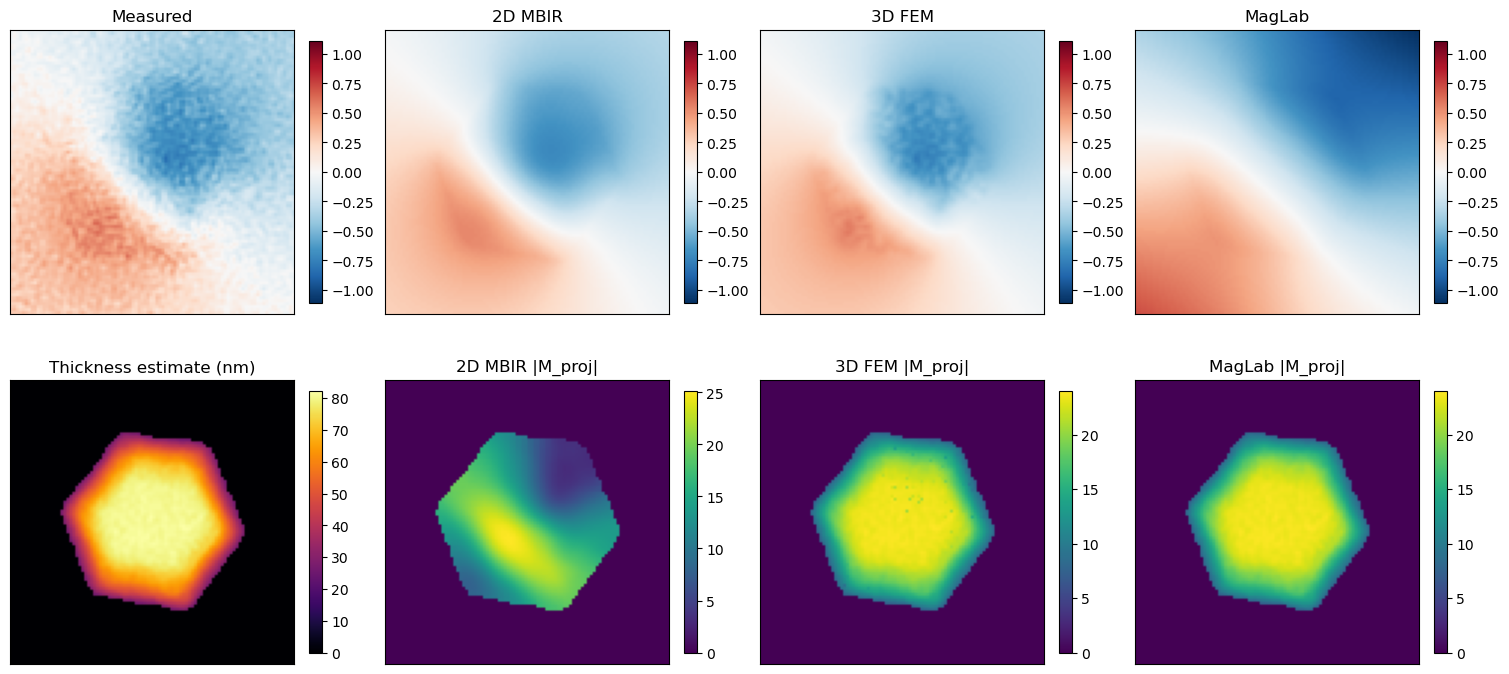

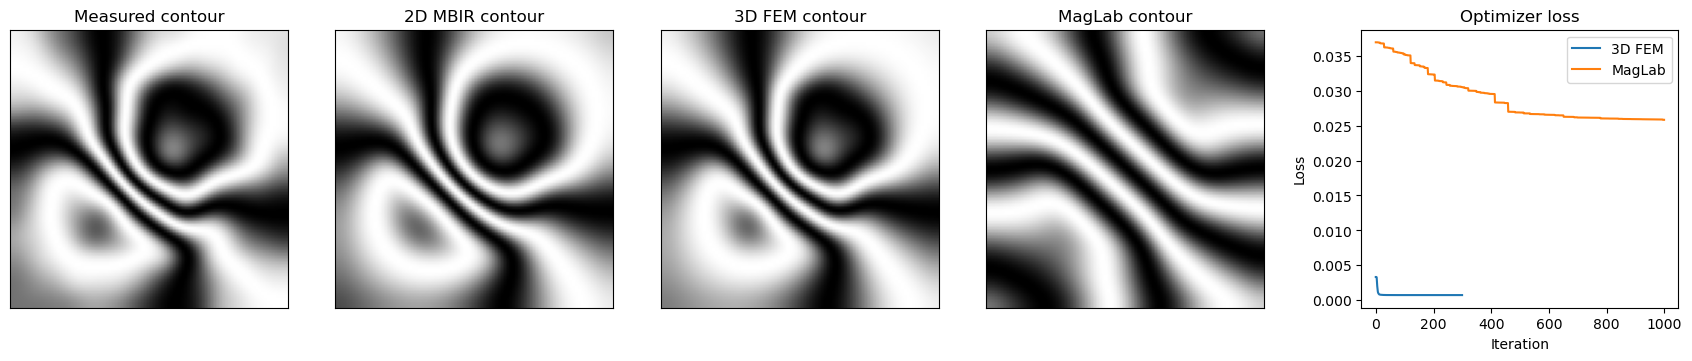

In [10]:
phase_vmax = max(
    np.max(np.abs(mag_small)),
    np.max(np.abs(pred_mbir)),
    np.max(np.abs(pred_fem)),
    np.max(np.abs(pred_maglab)),
    1e-12,
)

fig, axs = plt.subplots(2, 4, figsize=(15, 7), constrained_layout=True)
phase_rows = [
    ("Measured", mag_small),
    ("2D MBIR", pred_mbir),
    ("3D FEM", pred_fem),
    ("MagLab", pred_maglab),
]
for col_idx, (title, phase_img) in enumerate(phase_rows):
    im = axs[0, col_idx].imshow(phase_img, cmap="RdBu_r", vmin=-phase_vmax, vmax=phase_vmax)
    axs[0, col_idx].set_title(title)
    axs[0, col_idx].set_xticks([])
    axs[0, col_idx].set_yticks([])
    plt.colorbar(im, ax=axs[0, col_idx], fraction=0.046)

bottom_rows = [
    ("Thickness estimate (nm)", thickness_nm, "inferno"),
    ("2D MBIR |M_proj|", np.linalg.norm(proj_mbir, axis=-1), "viridis"),
    ("3D FEM |M_proj|", np.linalg.norm(proj_fem, axis=-1), "viridis"),
    ("MagLab |M_proj|", np.linalg.norm(proj_maglab, axis=-1), "viridis"),
]
for col_idx, (title, image, cmap) in enumerate(bottom_rows):
    im = axs[1, col_idx].imshow(image, cmap=cmap)
    axs[1, col_idx].set_title(title)
    axs[1, col_idx].set_xticks([])
    axs[1, col_idx].set_yticks([])
    plt.colorbar(im, ax=axs[1, col_idx], fraction=0.046)
plt.show()

measured_contour = np.cos(gaussian_filter(np.asarray(mag_small), sigma=4) * 16)
mbir_contour = np.cos(gaussian_filter(np.asarray(pred_mbir), sigma=4) * 16)
fem_contour = np.cos(gaussian_filter(np.asarray(pred_fem), sigma=4) * 16)
maglab_contour = np.cos(gaussian_filter(np.asarray(pred_maglab), sigma=4) * 16)

fig, axs = plt.subplots(1, 5, figsize=(17, 3.5), constrained_layout=True)
axs[0].imshow(measured_contour, cmap="gray")
axs[0].set_title("Measured contour")
axs[1].imshow(mbir_contour, cmap="gray")
axs[1].set_title("2D MBIR contour")
axs[2].imshow(fem_contour, cmap="gray")
axs[2].set_title("3D FEM contour")
axs[3].imshow(maglab_contour, cmap="gray")
axs[3].set_title("MagLab contour")
axs[4].plot(loss_history_fem, label="3D FEM")
axs[4].plot(loss_history_maglab, label="MagLab")
axs[4].set_title("Optimizer loss")
axs[4].set_xlabel("Iteration")
axs[4].set_ylabel("Loss")
axs[4].legend()
for ax in axs[:4]:
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

## 9. Volume Slices
Show every fourth z-slice for the FEM and MagLab 3D magnetization reconstructions.

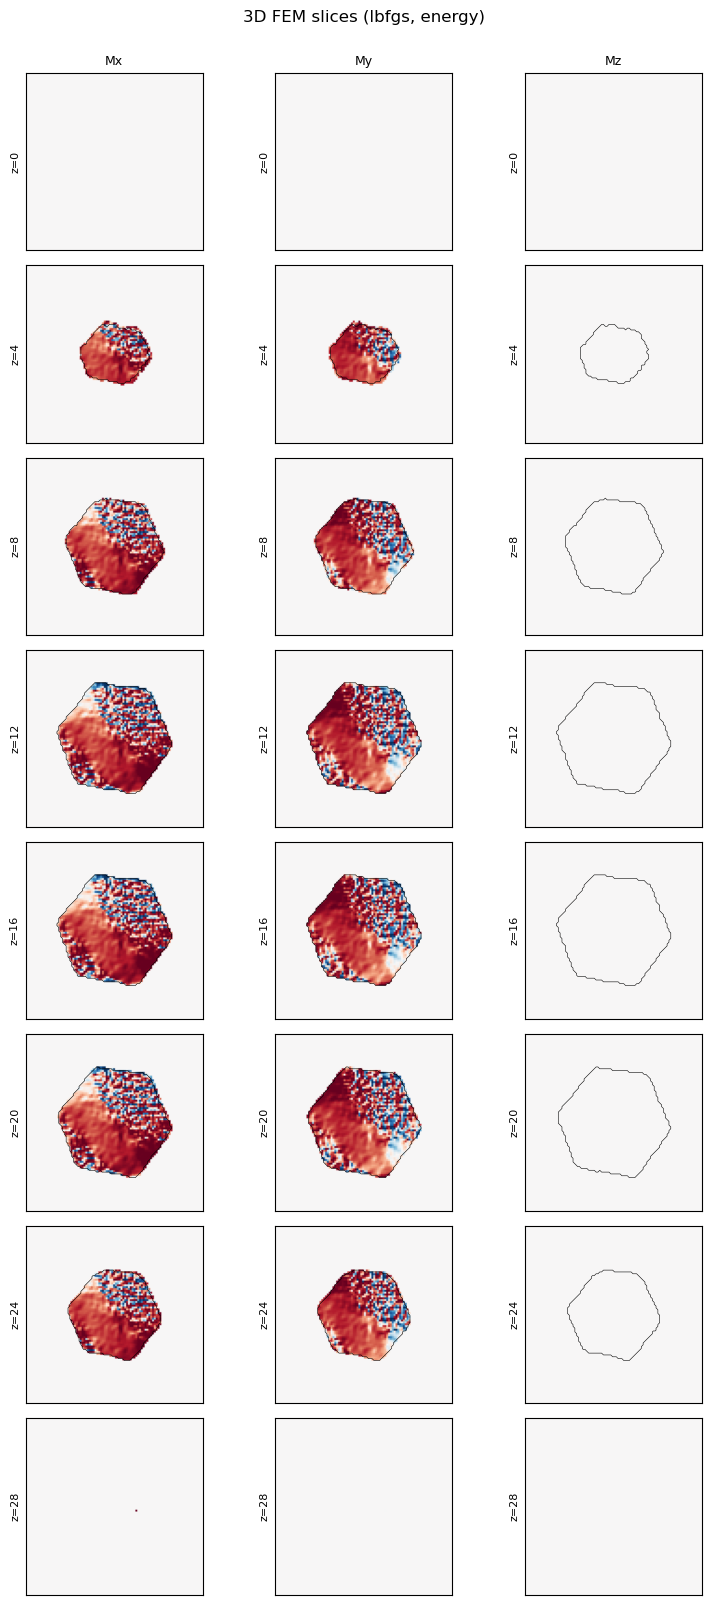

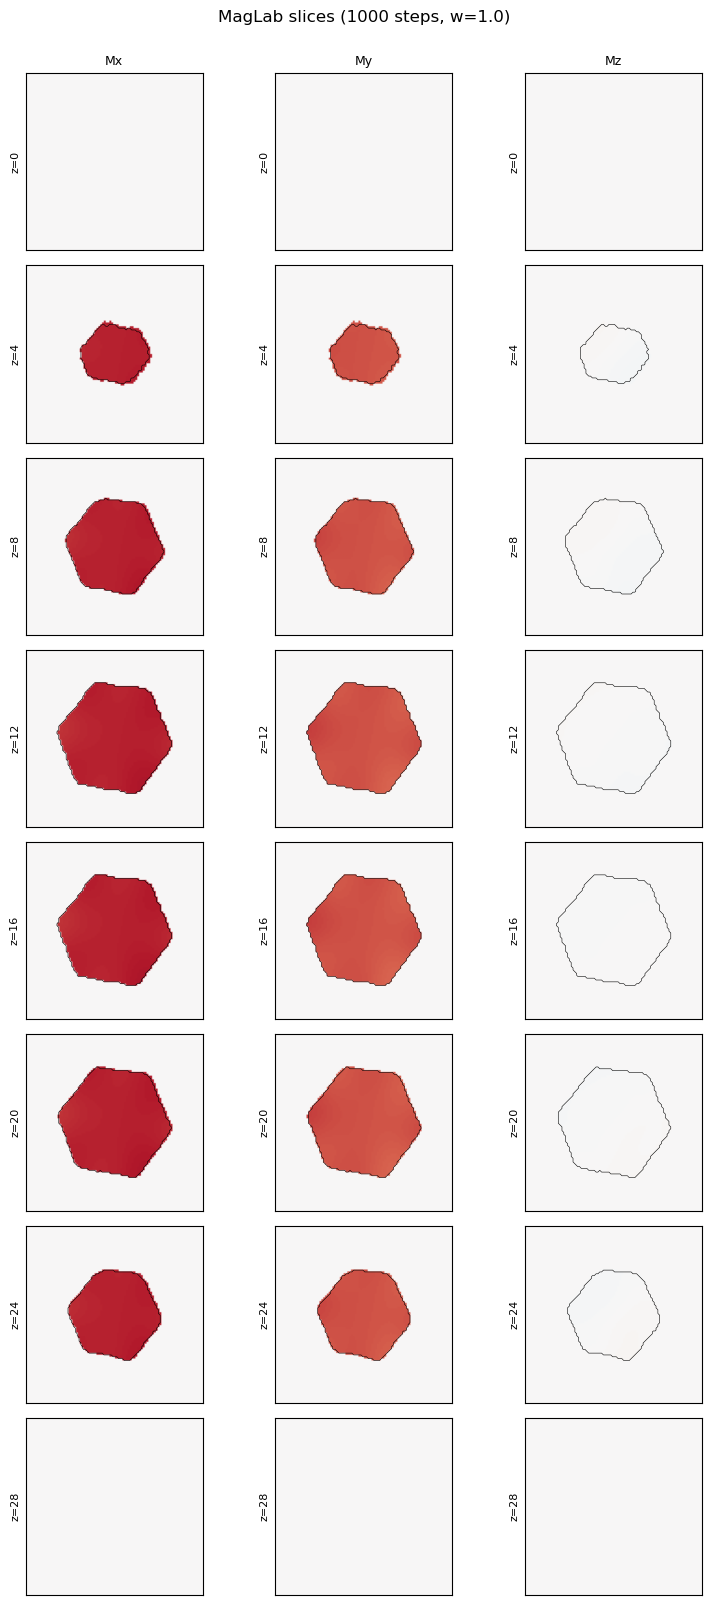

In [11]:
show_volume_slices(
    m_fem,
    rho_guess,
    f"3D FEM slices ({FEM_CONFIG['optimizer']}, {FEM_CONFIG['physics_objective']})",
)
show_volume_slices(
    m_maglab,
    rho_guess,
    f"MagLab slices ({MAGLAB_CONFIG['n_steps']} steps, w={MAGLAB_CONFIG['phase_weight']})",
)

## 10. Depth Profiles
Compare center-voxel and support-mean in-plane and out-of-plane components through depth for FEM and MagLab.

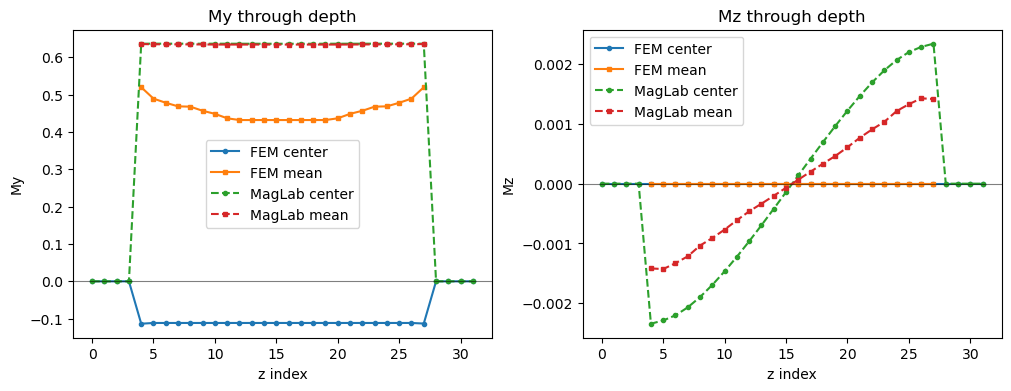

Center voxel (y, x): (48, 48)
FEM My center range: -0.11355394124984741 0.0
FEM Mz center range: 0.0 0.0
MagLab My center range: 0.0 0.636516273021698
MagLab Mz center range: -0.002343637403100729 0.0023436369374394417


In [12]:
m_fem_arr = np.asarray(m_fem, dtype=np.float32)
m_maglab_arr = np.asarray(m_maglab, dtype=np.float32)
z_axis = np.arange(m_fem_arr.shape[0])
y_center, x_center = yx_center
support_per_z = rho_guess > 0.25

my_center_fem = m_fem_arr[:, y_center, x_center, 1]
mz_center_fem = m_fem_arr[:, y_center, x_center, 2]
my_center_maglab = m_maglab_arr[:, y_center, x_center, 1]
mz_center_maglab = m_maglab_arr[:, y_center, x_center, 2]
my_mean_fem = np.array([
    np.mean(m_fem_arr[z_idx, ..., 1][support_per_z[z_idx]]) if np.any(support_per_z[z_idx]) else np.nan
    for z_idx in range(m_fem_arr.shape[0])
])
mz_mean_fem = np.array([
    np.mean(m_fem_arr[z_idx, ..., 2][support_per_z[z_idx]]) if np.any(support_per_z[z_idx]) else np.nan
    for z_idx in range(m_fem_arr.shape[0])
])
my_mean_maglab = np.array([
    np.mean(m_maglab_arr[z_idx, ..., 1][support_per_z[z_idx]]) if np.any(support_per_z[z_idx]) else np.nan
    for z_idx in range(m_maglab_arr.shape[0])
])
mz_mean_maglab = np.array([
    np.mean(m_maglab_arr[z_idx, ..., 2][support_per_z[z_idx]]) if np.any(support_per_z[z_idx]) else np.nan
    for z_idx in range(m_maglab_arr.shape[0])
])

fig, axs = plt.subplots(1, 2, figsize=(10, 3.8), constrained_layout=True)
axs[0].plot(z_axis, my_center_fem, marker="o", ms=3, label="FEM center")
axs[0].plot(z_axis, my_mean_fem, marker="s", ms=3, label="FEM mean")
axs[0].plot(z_axis, my_center_maglab, marker="o", ms=3, ls="--", label="MagLab center")
axs[0].plot(z_axis, my_mean_maglab, marker="s", ms=3, ls="--", label="MagLab mean")
axs[0].axhline(0.0, color="k", lw=0.8, alpha=0.5)
axs[0].set_title("My through depth")
axs[0].set_xlabel("z index")
axs[0].set_ylabel("My")
axs[0].legend()

axs[1].plot(z_axis, mz_center_fem, marker="o", ms=3, label="FEM center")
axs[1].plot(z_axis, mz_mean_fem, marker="s", ms=3, label="FEM mean")
axs[1].plot(z_axis, mz_center_maglab, marker="o", ms=3, ls="--", label="MagLab center")
axs[1].plot(z_axis, mz_mean_maglab, marker="s", ms=3, ls="--", label="MagLab mean")
axs[1].axhline(0.0, color="k", lw=0.8, alpha=0.5)
axs[1].set_title("Mz through depth")
axs[1].set_xlabel("z index")
axs[1].set_ylabel("Mz")
axs[1].legend()

plt.show()

print("Center voxel (y, x):", (y_center, x_center))
print("FEM My center range:", float(np.min(my_center_fem)), float(np.max(my_center_fem)))
print("FEM Mz center range:", float(np.min(mz_center_fem)), float(np.max(mz_center_fem)))
print("MagLab My center range:", float(np.min(my_center_maglab)), float(np.max(my_center_maglab)))
print("MagLab Mz center range:", float(np.min(mz_center_maglab)), float(np.max(mz_center_maglab)))